In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
def save_pkl(tgt_list, svg_path):
    with open(svg_path, "wb") as f:
        pickle.dump(tgt_list, f)

In [ ]:
df1 = pd.read_csv('topics/f1_submission.csv')
df2 = pd.read_csv('topics/f1_comment.csv')

df1['post_created_utc'] = pd.to_datetime(df1['post_created_utc'])
df2['comment_created_utc'] = pd.to_datetime(df2['comment_created_utc'])

print('Number of Submission:', df1.shape[0])
print('Number of Comments', df2.shape[0])

Number of Submission: 8006
Number of Comments 33981


In [ ]:
df1_pre = df1[df1.post_created_utc < '2020-01-01'].reset_index(drop=True)
df1_post = df1[df1.post_created_utc >= '2020-01-01'].reset_index(drop=True)

df2_pre = df2[df2.comment_created_utc < '2020-01-01'].reset_index(drop=True)
df2_post = df2[df2.comment_created_utc >= '2020-01-01'].reset_index(drop=True)

print('Number of posts before Covid-19:', df1_pre.shape[0])
print('Number of posts after Covid-19:', df1_post.shape[0])
print('\nNumber of comments before Covid-19:', df2_pre.shape[0])
print('Number of comments after Covid-19:', df2_post.shape[0])

Number of posts before Covid-19: 534
Number of posts after Covid-19: 7472

Number of comments before Covid-19: 1325
Number of comments after Covid-19: 32656


In [ ]:
#earliest timestamp
print('From:', df1['post_created_utc'].min())

#latest timestamp
print('To:', df1['post_created_utc'].max())

#difference between timestamps
print('Total:', df1['post_created_utc'].max() - df1['post_created_utc'].min())

From: 2015-08-20 17:27:20
To: 2022-12-31 16:50:26
Total: 2689 days 23:23:06


In [ ]:
# post_author
print('Number of authors created post:', len(set(df1.post_author)))
print('Number of authors before covid:', len(set(df1_pre.post_author)))
print('Number of authors after covid:', len(set(df1_post.post_author)))
print('Number of authors post both period:', len(set(df1_pre.post_author).intersection(set(df1_post.post_author))))

# comment_author
print('\nNumber of comment authors:', len(set(df2.comment_author)))
print('Number of comment uthors before covid:', len(set(df2_pre.comment_author)))
print('Number of comment authors after covid:', len(set(df2_post.comment_author)))
print('Number of comment authors post both period:', len(set(df2_pre.comment_author).intersection(set(df2_post.comment_author))))

# overall users..?
print('\nNumber of active users:', len(set(df1.post_author).union(set(df2.comment_author))))
print('Number of active users before covid:', len(set(df1_pre.post_author).union(set(df2_pre.comment_author))))
print('Number of active users after covid:', len(set(df1_post.post_author).union(set(df2_post.comment_author))))

Number of authors created post: 3814
Number of authors before covid: 325
Number of authors after covid: 3519
Number of authors post both period: 30

Number of comment authors: 5197
Number of comment uthors before covid: 326
Number of comment authors after covid: 4941
Number of comment authors post both period: 70

Number of active users: 6453
Number of active users before covid: 497
Number of active users after covid: 6047


In [ ]:
print('Number of posts without author overall:', df1[df1.post_author == '[deleted]'].shape[0])
print('Number of posts without author before covid:', df1_pre[df1_pre.post_author == '[deleted]'].shape[0])
print('Number of posts without author after covid:', df1_post[df1_post.post_author == '[deleted]'].shape[0])

print('\nNumber of comments without author overall:', df2[df2.comment_author == '[deleted]'].shape[0])
print('Number of comments without author before covid:', df2_pre[df2_pre.comment_author == '[deleted]'].shape[0])
print('Number of comments without author after covid:', df2_post[df2_post.comment_author == '[deleted]'].shape[0])

Number of posts without author overall: 1857
Number of posts without author before covid: 81
Number of posts without author after covid: 1776

Number of comments without author overall: 458
Number of comments without author before covid: 8
Number of comments without author after covid: 450


In [ ]:
post_count = df1.groupby(['post_author']).size().reset_index(name='post_count')
post_count = post_count[post_count['post_author'] != '[deleted]']

post_count_count = post_count.groupby('post_count').size().reset_index(name='count')
post_count_count.head(2)

,post_count,count
0,1,2836
1,2,513


In [ ]:
def author_count(authors):
    authors = [author for author in authors if author != '[deleted]']
    author_cnt = Counter(authors)
    author_cnt = dict(author_cnt)
    return author_cnt

author_dict = author_count(list(df1.post_author))
above5_author_dict = {k:v for k, v in author_dict.items() if v > 5}
len(above5_author_dict)

110

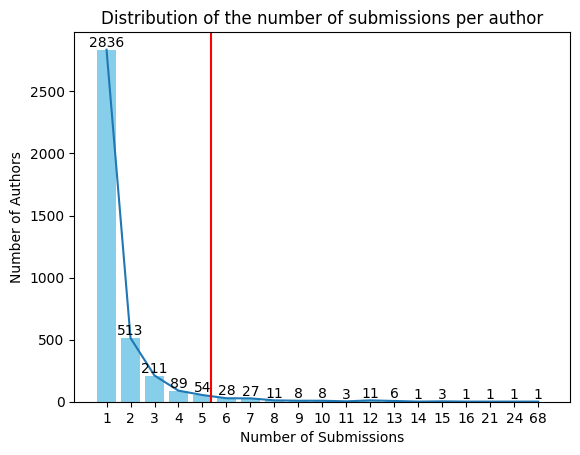

In [ ]:
data = list(post_count_count['count'])
original_x_values = list(post_count_count['post_count'])

constant_gap = 1
continuous_x_values = np.arange(len(original_x_values)) * constant_gap


val = list(post_count['post_count'])
mean = np.mean(val)
std = np.std(val)
x = mean + 1.96*std


plt.bar(continuous_x_values, data, color='skyblue')
plt.plot(continuous_x_values, data)
plt.axvline(x = x-1, color = 'red', label = 'axvline - full height')
plt.xlabel('Number of Submissions')
plt.ylabel('Number of Authors')
plt.xticks(continuous_x_values, original_x_values)
for i, value in enumerate(data):
  plt.text(continuous_x_values[i], value, str(value), ha='center', va='bottom')
plt.title('Distribution of the number of submissions per author')
plt.show()

In [ ]:
post_count_pre = df1_pre.groupby(['post_author']).size().reset_index(name='post_count')
post_count_pre = post_count_pre[post_count_pre['post_author'] != '[deleted]']

post_count_count_pre = post_count_pre.groupby('post_count').size().reset_index(name='count')
post_count_count_pre

,post_count,count
0,1,286
1,2,25
2,3,7
3,4,3
4,5,1
5,11,1
6,68,1


[286, 25, 7, 3, 1, 1, 1]
[np.float64(0.8827), np.float64(0.0772), np.float64(0.0216), np.float64(0.0093), np.float64(0.0031), np.float64(0.0031), np.float64(0.0031)]


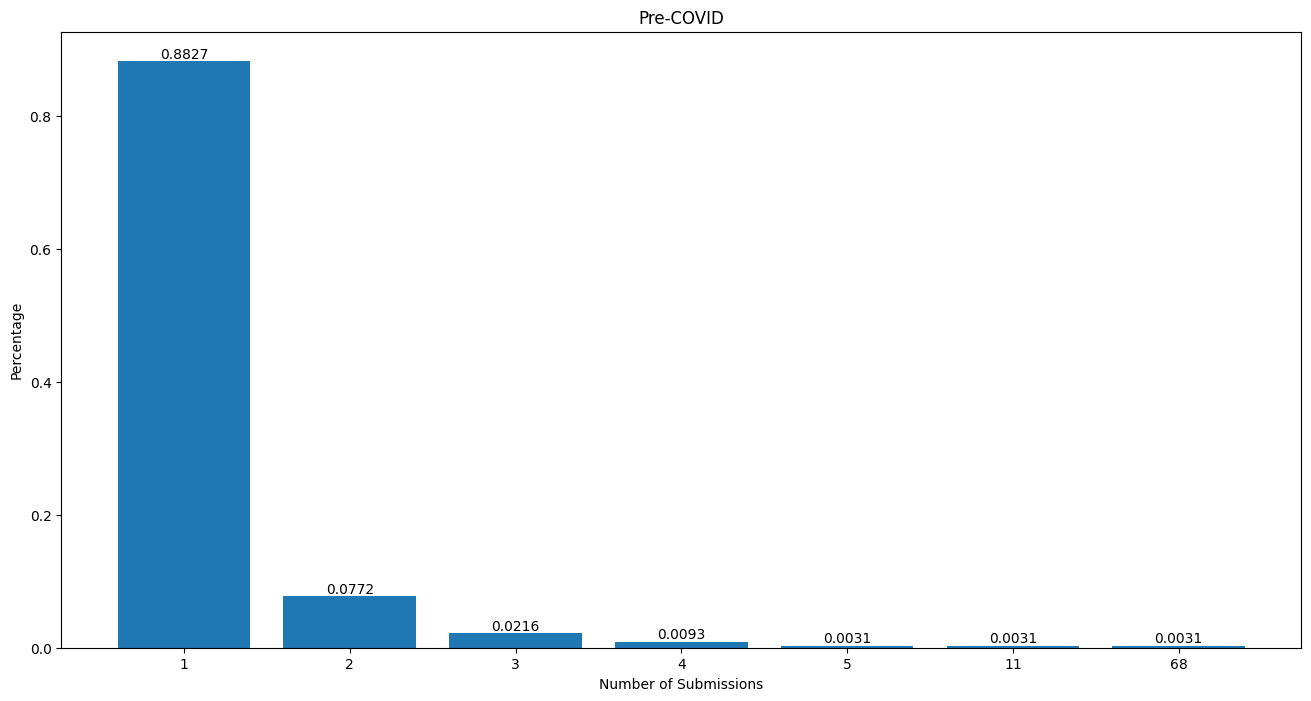

In [ ]:
data = list(post_count_count_pre['count'])
new_data = [round(d/np.sum(data),4) for d in data]
print(data)
print(new_data)
original_x_values = list(post_count_count_pre['post_count'])

plt.subplots(figsize=(16,8))
constant_gap = 1
continuous_x_values = np.arange(len(original_x_values)) * (constant_gap)

plt.bar(continuous_x_values, new_data)
plt.xlabel('Number of Submissions')
plt.ylabel('Percentage')
plt.xticks(continuous_x_values, original_x_values)
for i, value in enumerate(new_data):
  plt.text(continuous_x_values[i], value, str(value), ha='center', va='bottom')
plt.title('Pre-COVID')
plt.show()

In [ ]:
post_count_post = df1_post.groupby(['post_author']).size().reset_index(name='post_count')
post_count_post = post_count_post[post_count_post['post_author'] != '[deleted]']

post_count_count_post = post_count_post.groupby('post_count').size().reset_index(name='count')
post_count_count_post.tail(2)

,post_count,count
15,21,1
16,24,1


[2587, 482, 205, 88, 49, 29, 26, 12, 8, 7, 2, 10, 7, 3, 1, 1, 1]
[np.float64(0.7354), np.float64(0.137), np.float64(0.0583), np.float64(0.025), np.float64(0.0139), np.float64(0.0082), np.float64(0.0074), np.float64(0.0034), np.float64(0.0023), np.float64(0.002), np.float64(0.0006), np.float64(0.0028), np.float64(0.002), np.float64(0.0009), np.float64(0.0003), np.float64(0.0003), np.float64(0.0003)]


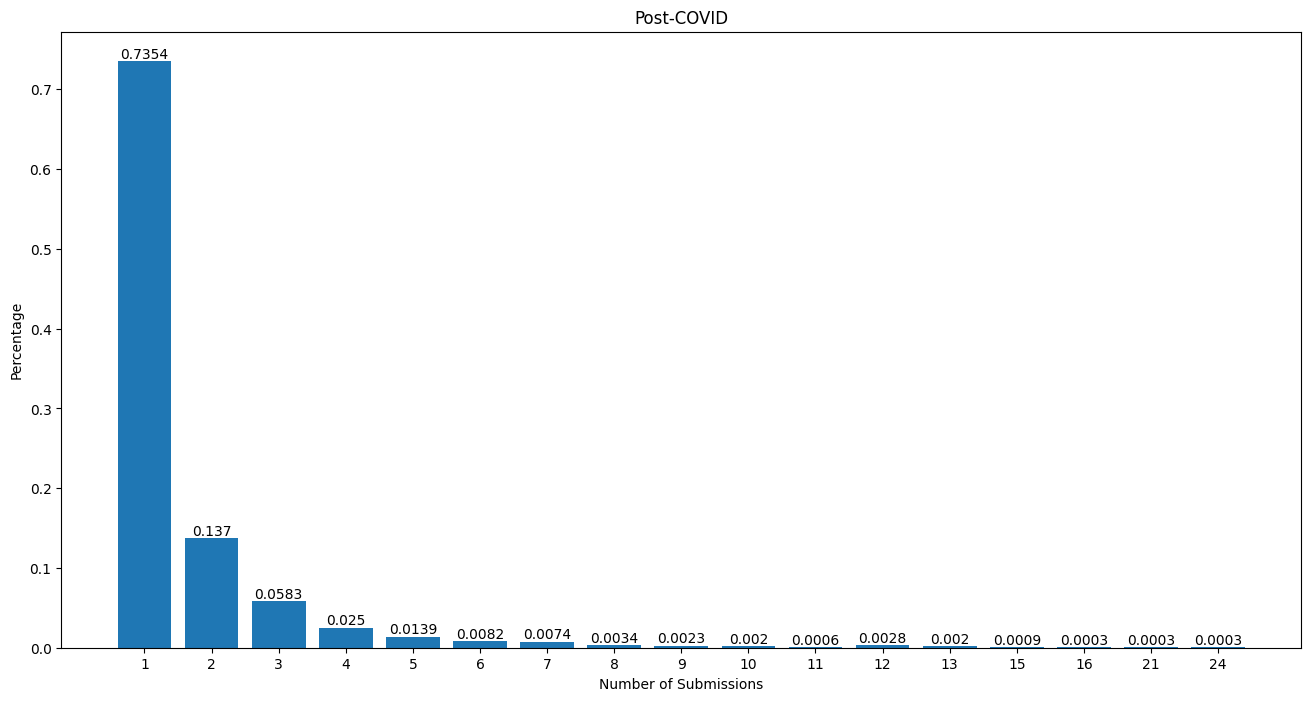

In [ ]:
import matplotlib.pyplot as plt
data = list(post_count_count_post['count'])
new_data = [round(d/np.sum(data),4) for d in data]
print(data)
print(new_data)
original_x_values = list(post_count_count_post['post_count'])

constant_gap = 1
continuous_x_values = np.arange(len(original_x_values)) * (constant_gap)

plt.subplots(figsize=(16,8))
plt.bar(continuous_x_values, new_data)
plt.xlabel('Number of Submissions')
plt.ylabel('Percentage')
plt.xticks(continuous_x_values, original_x_values)
for i, value in enumerate(new_data):
  plt.text(continuous_x_values[i], value, str(value), ha='center', va='bottom')
plt.title('Post-COVID')
plt.show()